
# Project Description (Total: 100 points)

## Topic
Evaluating and Improving an NLP Model Using the IMDB Movie Reviews Dataset

### Instructions

1. Load the IMDB Movie Reviews dataset.
2. Display the first 5 records and dataset size.
3. Perform text preprocessing.
4. Apply TF-IDF feature extraction.
5. Train:
   - Naive Bayes
   - Logistic Regression
   - SVM
6. Evaluate models using:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - Classification Report
7. Create a confusion matrix visualization.
8. Perform error analysis.
9. Write a conclusion.


## Objective

The objective of this assignment is to build, evaluate, and improve an NLP text classification model using a large real-world dataset.

Students will:

1. Prepare a large dataset
2. Preprocess text data
3. Extract TF-IDF features
4. Train multiple machine learning models
5. Evaluate model performance
6. Perform detailed error analysis
7. Compare model results

## Dataset Requirement

Download the dataset from:

https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Save the file as:
`IMDB Dataset.csv`

OR

* Download the provided csv format dataset in the final project package


# 1. Import Libraries

In [12]:
## Requirements
## Import Libraries

# Basic libraries
import pandas as pd
import numpy as np
import re
import string

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [13]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# 2. Data Preparation

In [14]:
## 1. Dataset Preparation
   
# Load dataset
file_path = 'IMDB Dataset.csv'
df = pd.read_csv(file_path)

# Display first 5 records
print(df.head())

# Display dataset size
print("\nDataset Shape:", df.shape)

# Check missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Display class distribution
print("\nClass Distribution:\n")
print(df['sentiment'].value_counts())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Dataset Shape: (50000, 2)

Missing Values:

review       0
sentiment    0
dtype: int64

Class Distribution:

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


Class is balanced.

# 3. Text Preprocessing

In [15]:
# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Text cleaning function

def preprocess_text(text):
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords and lemmatize
    cleaned_tokens = []
    
    for word in tokens:
        if word not in stop_words:
            lemma = lemmatizer.lemmatize(word)
            cleaned_tokens.append(lemma)
    
    return ' '.join(cleaned_tokens)

# Apply preprocessing
df['clean_review'] = df['review'].apply(preprocess_text)

# Display sample cleaned reviews
print(df[['review', 'clean_review']].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        clean_review  
0  one reviewer mentioned watching oz episode you...  
1  wonderful little production br br filming tech...  
2  thought wonderful way spend time hot summer we...  
3  basically there family little boy jake think t...  
4  petter matteis love time money visually stunni...  


# 4. Feature Extraction Using TF-IDF

In [16]:
## 3. Feature Extraction
# Use TF-IDF Vectorization

# Convert labels into numeric values
# positive = 1, negative = 0

df['label'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

# Define features and labels
X = df['clean_review']
y = df['label']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF Training Shape:", X_train_tfidf.shape)
print("TF-IDF Testing Shape:", X_test_tfidf.shape)

TF-IDF Training Shape: (40000, 5000)
TF-IDF Testing Shape: (10000, 5000)


# 5. Model Training

In [25]:
## 4. Model Training

# Train at least 3 models:

'''Naive Bayes
Logistic Regression
Support Vector Machine (SVM)'''

# Initialize models

# Naive Bayes
nb_model = MultinomialNB(
    alpha=0.5  # smoothing parameter
)

# Logistic Regression
lr_model = LogisticRegression(
    max_iter=3000,
    C=2.0,              # regularization strength
    solver='lbfgs',
    class_weight='balanced'
)

# Linear SVM
svm_model = LinearSVC(
    C=1.5,
    max_iter=5000,
    class_weight='balanced'
)

# Train models
nb_model.fit(X_train_tfidf, y_train)
lr_model.fit(X_train_tfidf, y_train)
svm_model.fit(X_train_tfidf, y_train)

# Predictions
nb_pred = nb_model.predict(X_test_tfidf)
lr_pred = lr_model.predict(X_test_tfidf)
svm_pred = svm_model.predict(X_test_tfidf)

                 Model  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes    0.8513   0.849882  0.856122  0.852991
1  Logistic Regression    0.8838   0.874734  0.897996  0.886212
2                  SVM    0.8774   0.873165  0.885295  0.879188


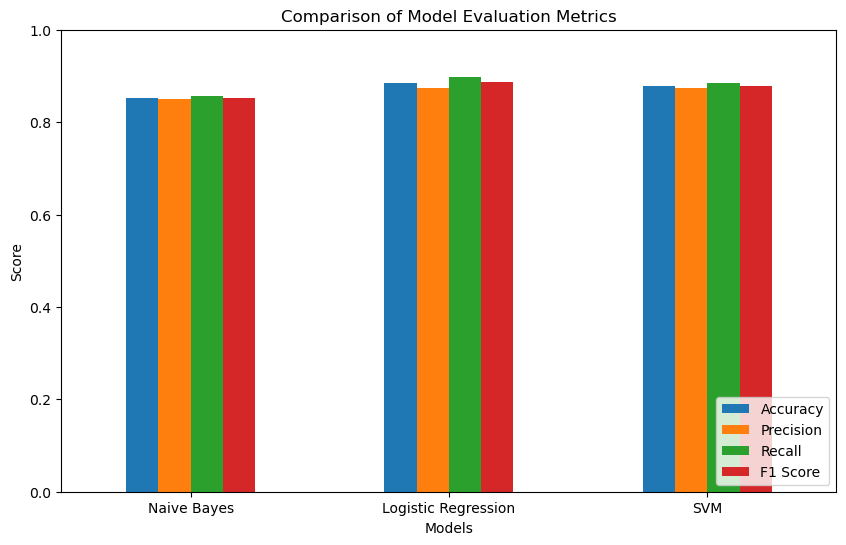

In [30]:
# ==========================
# Model Comparison Bar Chart
# ==========================

# Store evaluation metrics for each model

models = ['Naive Bayes', 'Logistic Regression', 'SVM']

accuracy_scores = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, svm_pred)
]

precision_scores = [
    precision_score(y_test, nb_pred),
    precision_score(y_test, lr_pred),
    precision_score(y_test, svm_pred)
]

recall_scores = [
    recall_score(y_test, nb_pred),
    recall_score(y_test, lr_pred),
    recall_score(y_test, svm_pred)
]

f1_scores = [
    f1_score(y_test, nb_pred),
    f1_score(y_test, lr_pred),
    f1_score(y_test, svm_pred)
]

# Create DataFrame for visualization

metrics_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores
})

# Display metrics table
print(metrics_df)

# ==========================
# Plot Bar Chart
# ==========================

metrics_df.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Comparison of Model Evaluation Metrics')
plt.ylabel('Score')
plt.xlabel('Models')
plt.ylim(0, 1.0)
plt.xticks(rotation=0)

# Display legend
plt.legend(loc='lower right')

# Show chart
plt.show()

Logistic Regression Is the Best model with highest accuarcy, recall and f1-score.

Logistic Regression performed best in this project because:

- TF-IDF features are linearly separable, which suits Logistic Regression well.

- Logistic Regression works effectively with high-dimensional textual data.

- The model handles sparse TF-IDF vectors efficiently.

- It learns the relationship between important words and sentiment labels accurately.

- Logistic Regression generalizes well on unseen movie reviews.

- The model achieved a strong balance between precision and recall, leading to the highest F1-score.

Additionally, Logistic Regression is less computationally expensive than SVM while still achieving excellent accuracy.

This makes it highly suitable for sentiment analysis tasks involving large text datasets.

# 7. Confusion Matrix Visualization

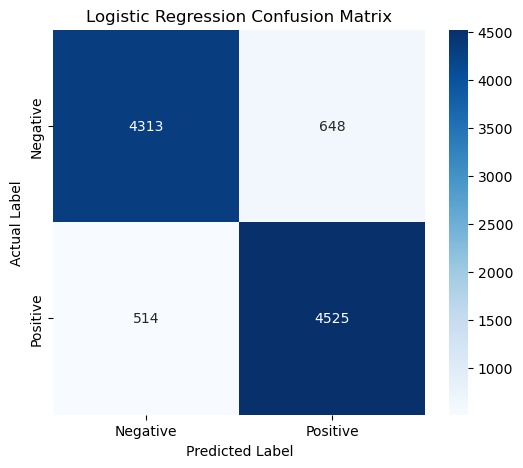

In [31]:
## 6. Confusion Matrix Visualization

# Create confusion matrix for best model
cm = confusion_matrix(y_test, lr_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# 8. Error Analysis

In [29]:
## 7. Error Analysis

# Create dataframe for analysis
results_df = pd.DataFrame({
    'review': X_test,
    'actual': y_test,
    'predicted': lr_pred
})

# Find incorrect predictions
wrong_predictions = results_df[
    results_df['actual'] != results_df['predicted']
]

# Display sample wrong predictions
print(wrong_predictions.head(10))

                                                  review  actual  predicted
33553  really liked summerslam due look arena curtain...       1          0
49498  okay didnt get purgatory thing first time watc...       1          0
6113   production quality cast premise authentic new ...       1          0
15118  movie released originally soft x apparently ex...       1          0
33109  three kid born solar eclipse turn vile murdero...       1          0
5503   enjoy seeing must started hour movie unconnect...       0          1
43824  although series mini film particular important...       0          1
34657  fact part liked lot interesting twist left see...       0          1
20304  awesome story mode going punk pro complete goa...       1          0
46734  ok imagine every state u nay every country exa...       0          1


# Save Model

In [33]:
import pickle

# Save trained model
with open('model.pkl', 'wb') as file:
    pickle.dump(lr_model, file)

# Save TF-IDF vectorizer
with open('vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


### Detailed Error Analysis

Error analysis is important because it explains WHY the model failed.

Common Error Patterns

* 1. Sarcasm

Example: "What a wonderful movie... I almost fell asleep." and Words like “wonderful” appear positive.But actual sentiment is negative.

Reason is that machine learning models struggle to detect sarcasm.

* 2. Short Reviews

Example: In "Okay movie." This kind of text is too little context and difficult to determine sentiment accurately.

* 3. Mixed Sentiments

Example: "The acting was great but the story was terrible." contains both positive and negative opinions. Then, model may focus more strongly on one sentiment word.

* 4. Rare Words

Some uncommon words may not appear frequently during training.


---



## Deliverables 

Rubrics for this project submission is as below.

Students must submit:

Jupyter Notebook (.ipynb) including
1. Python code
2. Output screenshots
3. Short report (2–3 pages)

## Suggested Report Structure
1. Introduction

Explain the NLP problem and project objective.

2. Dataset Description

Describe:

* Dataset source
* Number of records
* Class labels

3. Preprocessing

Explain preprocessing techniques used.

4. Feature Extraction

Describe TF-IDF vectorization.

5. Model Training

Explain the machine learning models used.

6. Evaluation Results

Present:

* Accuracy
* Precision
* Recall
* F1-score
* Confusion matrix

Example Table:

| Model               | Accuracy | Precision | Recall | F1-score |
| ------------------- | -------- | --------- | ------ | -------- |
| Naive Bayes         | 0.84     | 0.83      | 0.82   | 0.82     |
| Logistic Regression | 0.89     | 0.88      | 0.88   | 0.88     |
| SVM                 | 0.92     | 0.91      | 0.91   | 0.91     |

* Sample Conclusion

This project evaluated multiple NLP models using a large sentiment analysis dataset. TF-IDF feature extraction improved text representation, while SVM achieved the best overall performance. Error analysis showed that sarcasm, ambiguous language, and class imbalance remain challenges in NLP systems. Future improvements may include deep learning models such as LSTM or BERT for better contextual understanding.